## ⚙️ Instalaciones

In [1]:
%%capture

!pip install langfuse pandas scikit-learn matplotlib seaborn;

In [2]:
import os
from langfuse import Langfuse
from dotenv import load_dotenv

# Cargar las variables desde el archivo .env
load_dotenv()

# Acceder a las variables
LANGFUSE_PUBLIC_KEY = os.getenv("LANGFUSE_PUBLIC_KEY")
LANGFUSE_SECRET_KEY = os.getenv("LANGFUSE_SECRET_KEY")
LANGFUSE_HOST = os.getenv("LANGFUSE_HOST")

# Configurar intancia de Langfuse 
langfuse = Langfuse(
    public_key=LANGFUSE_PUBLIC_KEY,
    secret_key=LANGFUSE_SECRET_KEY,
    host=LANGFUSE_HOST
)

## ⬇️ Obtención de Datos y Definición del Ground Truth

Para evaluar nuestros modelos, comparamos el puntaje de similitud (*retrieval score*) frente a la realidad de los datos (*ground truth*). Definimos nuestro problema de clasificación binaria de la siguiente manera:

* **Clase 1 (Positiva - *Satisfy*):** Consultas para las cuales existe información relevante en la base de conocimiento. Esperamos scores altos.
* **Clase 0 (Negativa - *Dissatisfy*):** Consultas etiquetadas como 'Sin Información'. Aquí el sistema idealmente no debería recuperar contexto (o tener un score muy bajo).

A continuación, construimos un `ground_truth_map` asignando un **0** a las trazas sin información y un **1** al resto.

In [3]:
# Conjunto de datos ejecutado en todos los experimentos
DATASET_NAME = "faq_dataset_v1" 

# Obtener items del conjunto de datos
dataset_items = langfuse.api.dataset_items.list(dataset_name=DATASET_NAME, limit=100).data

# Construir mapa de ground truth
ground_truth_map = {}

for item in dataset_items:
  # Obtener categoría y definir clase
  category = item.metadata
  ground_truth = 0 if category == 'Sin Información' else 1

  # Guardamos usando id del dataset la clase esperada 
  ground_truth_map[item.id] = ground_truth

print(f"✅ Mapa de verdad construido para {len(ground_truth_map)} items.")  

✅ Mapa de verdad construido para 100 items.


## 🛠️ Construcción del Dataframe

In [4]:
import pandas as pd

# Obtener los dataset runs asociados al dataset
dataset_runs = langfuse.api.datasets.get_runs(dataset_name=DATASET_NAME).data

# Filtrar los asociados a este experimento sobre embeddings
experiment_runs = [run for run in dataset_runs if run.name.startswith('experiment-embedding')]

# Armar filas para el Dataframe
data_rows = []

for run in experiment_runs:
  # Extraer nombre del modelo desde nombre del experimento
  model_name = run.name.replace("experiment-embedding-", "").rsplit("-v1", 1)[0].split("-", 1)[1]
  print(f"⚙️ Procesando Run: {model_name}")

  # Obtener trazas asociadas a los run items
  run_items = langfuse.api.dataset_run_items.list(dataset_id=run.dataset_id, run_name=run.name, limit=100).data
  for run_item in run_items:
    # Obtener clase esperada
    gt = ground_truth_map.get(run_item.dataset_item_id)

    # Obtener traza
    trace = langfuse.api.trace.get(run_item.trace_id)

    # Obtener la puntuación de similitud del mejor rankeado
    best_retrieval_score = trace.output[0].get('score')

    # Armar fila para el Dataframe
    data_rows.append({
      'model': model_name,
      'y_true': gt,
      'y_score': best_retrieval_score
    })

df = pd.DataFrame(data_rows)
print(f"\n✅ Procesamiento finalizado. {len(df)} puntos de datos listos.")

⚙️ Procesando Run: sts-multilingual-mpnet-base-v2
⚙️ Procesando Run: e5-mistral-7b-instruct-q4
⚙️ Procesando Run: bge-m3
⚙️ Procesando Run: jina-embeddings-v2-base-es
⚙️ Procesando Run: embeddinggemma-300m
⚙️ Procesando Run: qwen3-embedding-0-6b
⚙️ Procesando Run: qwen3-embedding-4b
⚙️ Procesando Run: multilingual-e5-large-instruct
⚙️ Procesando Run: distiluse-base-multilingual-cased-v1
⚙️ Procesando Run: nomic-embed-text-v2-moe-latest
⚙️ Procesando Run: nomic-embed-text-latest
⚙️ Procesando Run: qwen3-embedding-8b
⚙️ Procesando Run: gemini-embedding-exp-03-07
⚙️ Procesando Run: gemini-embedding-001
⚙️ Procesando Run: text-embedding-004

✅ Procesamiento finalizado. 1500 puntos de datos listos.


## 📐 Calculo de FPR y TPR

In [5]:
from sklearn.metrics import roc_curve, auc, roc_auc_score

model_stats = []
unique_models = df['model'].unique()

# Calcular ROC AUC para cada modelo del experimento
for model in unique_models:
  subset = df[df['model'] == model]
        
  fpr, tpr, thresholds = roc_curve(subset['y_true'], subset['y_score'])

  if subset['y_true'].nunique() < 2:
    continue
    
  roc_auc = auc(fpr, tpr)
  roc_auc_metric = roc_auc_score(subset['y_true'], subset['y_score'])

  # Asegurar precisión en la estimación del roc_auc
  assert abs(roc_auc_metric - roc_auc) < 1e-6
    
  model_stats.append({
      'model': model,
      'auc': roc_auc,
      'fpr': fpr,
      'tpr': tpr,
      'thresholds': thresholds 
  })

# Ordenamos de mayor a menor AUC
model_stats.sort(key=lambda x: x['auc'], reverse=True)

## 📈 Graficar Curva AUC

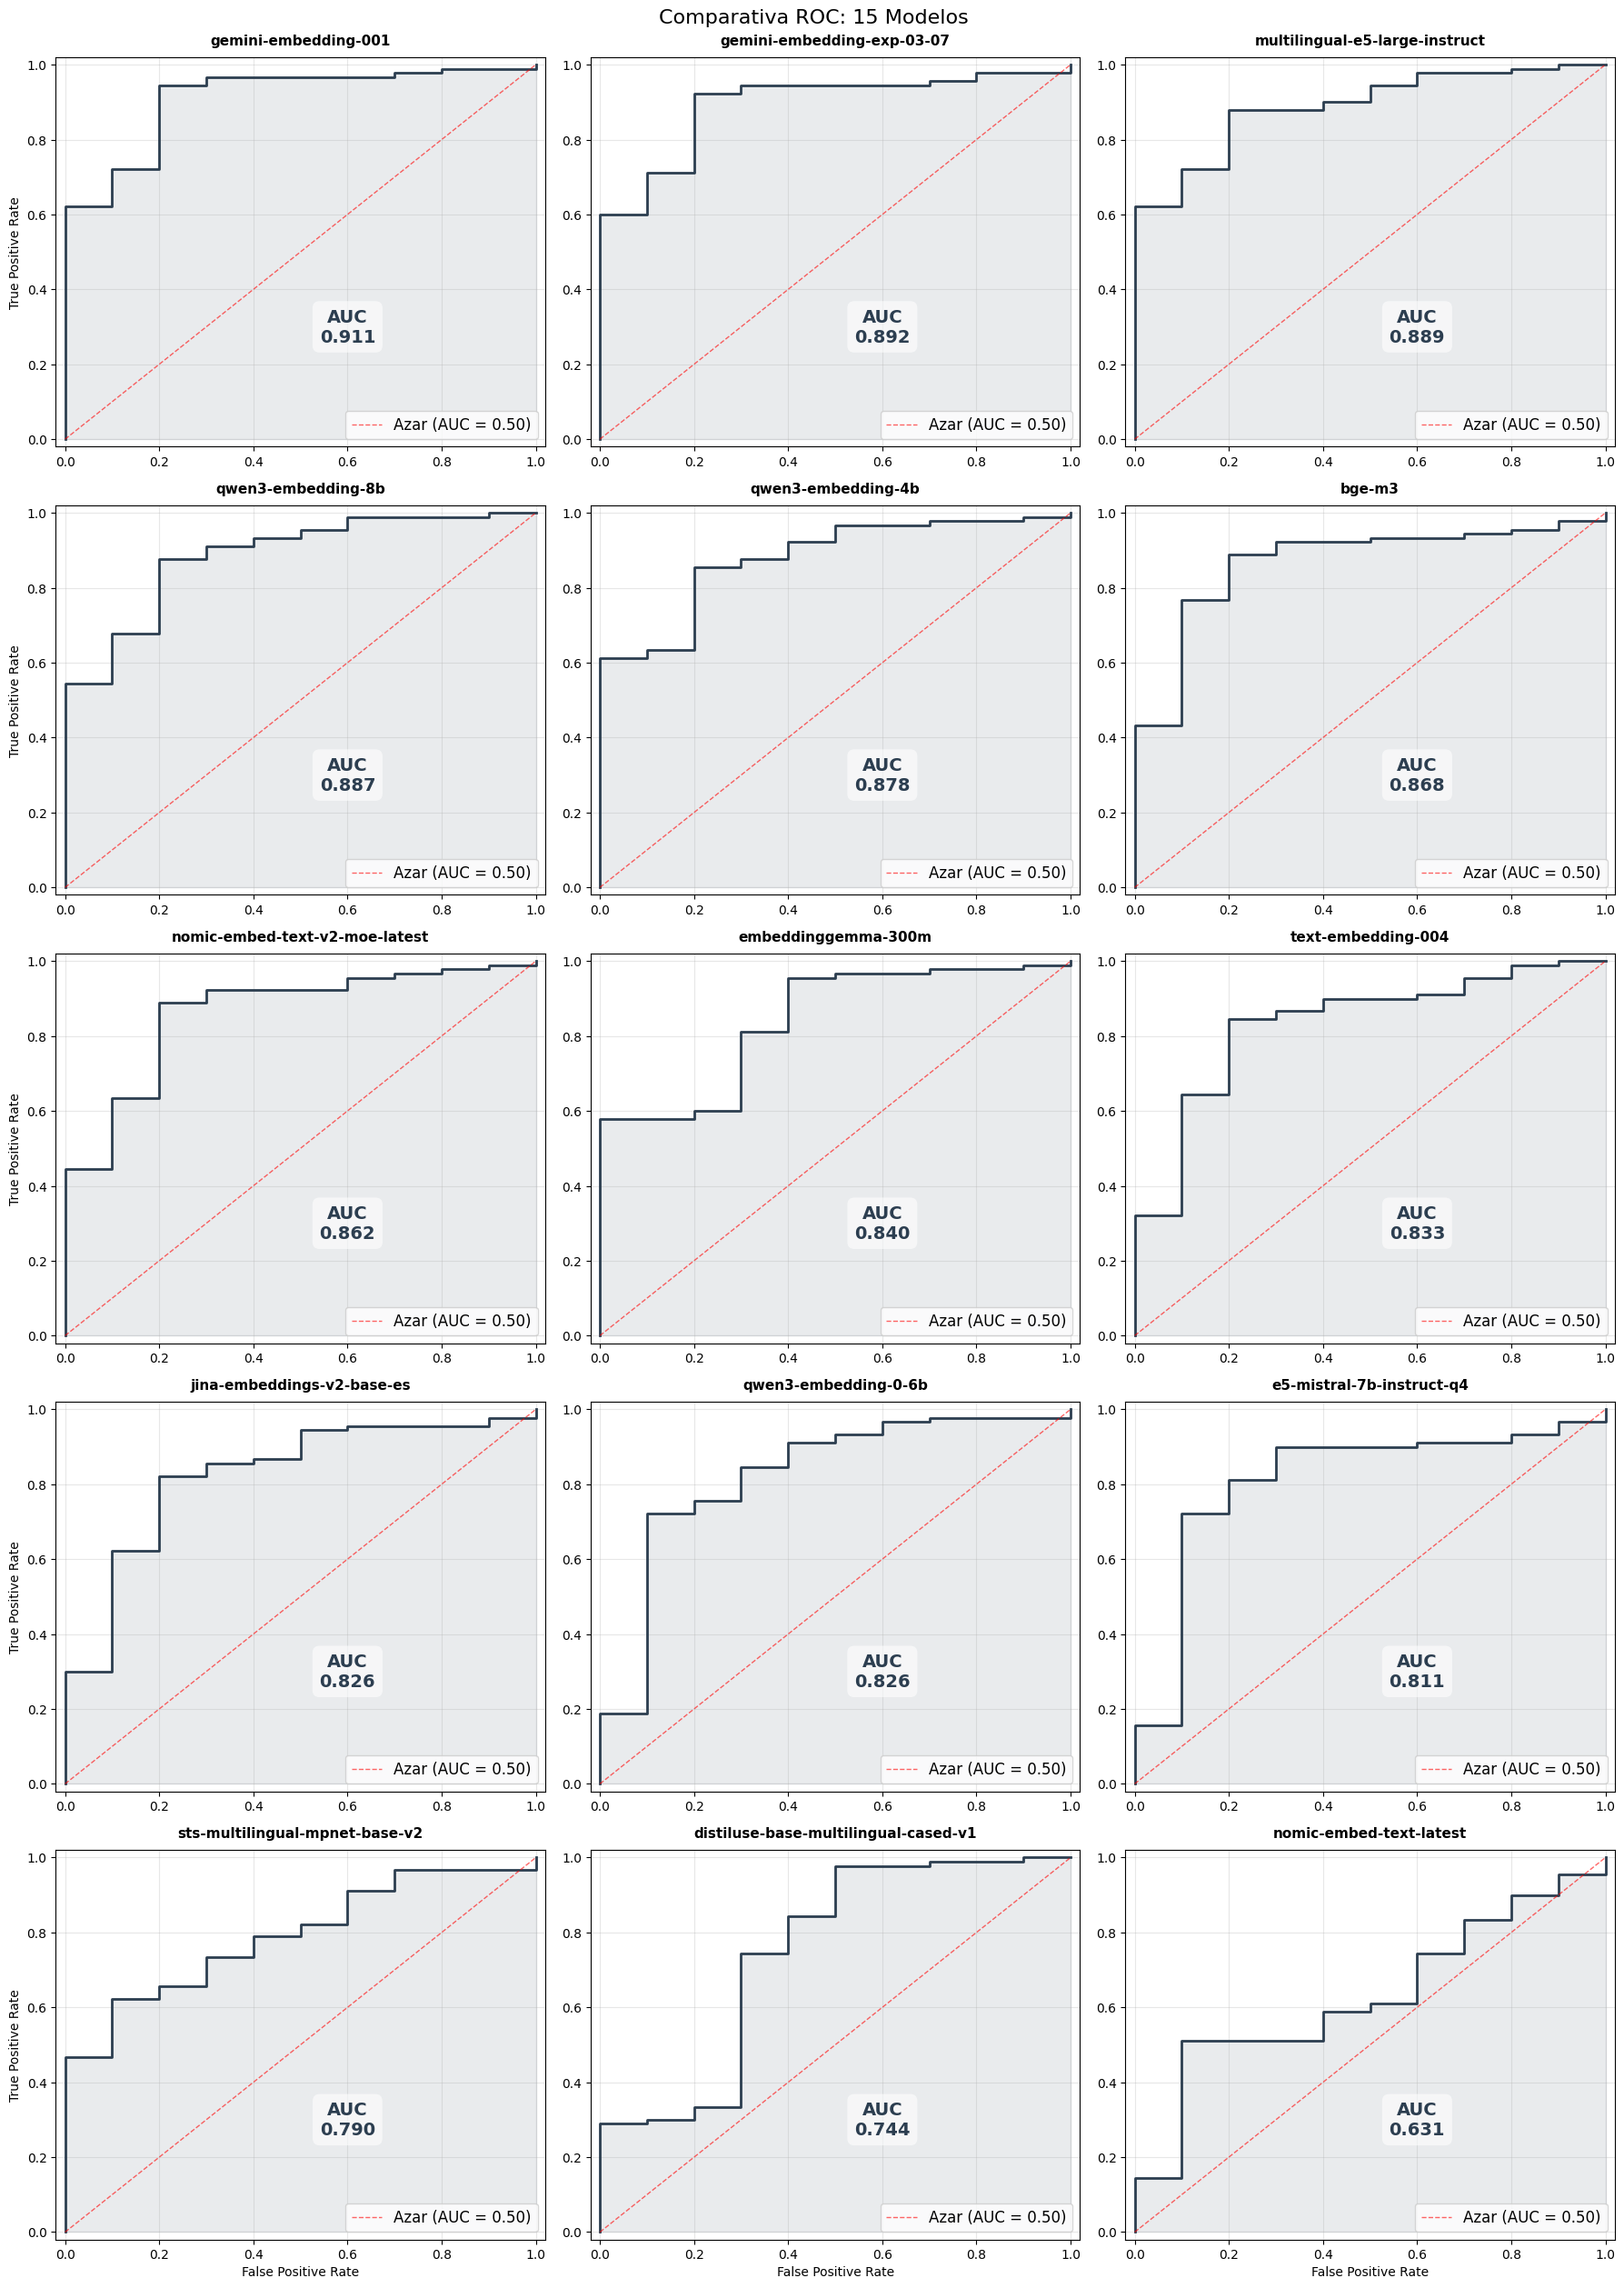

In [6]:
import math
import matplotlib.pyplot as plt

# Configuración de la Grilla
n_models = len(model_stats)
n_cols = 3
n_rows = math.ceil(n_models / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < n_models:
        data = model_stats[i]
        
        # AUC
        ax.fill_between(data['fpr'], data['tpr'], color='#2c3e50', alpha=0.1)
        
        # Curva ROC 
        ax.plot(data['fpr'], data['tpr'], color='#2c3e50', lw=2)
        
        # Puntuación ROC_AUC dentro de la curva 
        ax.text(
            0.60, 0.30, 
            f"AUC\n{data['auc']:.3f}", 
            fontsize=14, 
            fontweight='bold',
            color='#2c3e50',
            ha='center', va='center',
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="none", alpha=0.6)
        )
        
        # ROC_AUC 0.5
        ax.plot([0, 1], [0, 1], 'r--', lw=1, alpha=0.6, label='Azar (AUC = 0.50)')
        
        # Estética
        ax.set_title(data['model'], fontsize=11, fontweight='bold', pad=10)
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
        ax.grid(True, alpha=0.3)
        
        ax.legend(loc="lower right", fontsize=12)
        
        if i % n_cols == 0:
            ax.set_ylabel('True Positive Rate')
        if i >= n_models - n_cols:
            ax.set_xlabel('False Positive Rate')
            
    else:
        ax.axis('off')

plt.tight_layout()
plt.suptitle(f"Comparativa ROC: {n_models} Modelos", y=1.005, fontsize=16)
plt.show()

## 📏 Calcular F1-Score Macro

Para los 6 modelos con mejor desempeño, procedemos a calcular el **F1-Score Macro**. A diferencia del AUC, que evalúa el ranking general, el F1 requiere la predicción de clase obtenida con el modelo.

Para ello, necesitaremos de un **umbral de corte**, que en nuestro caso queremos que sea balanceado, para cada modelo. Este umbral busca el punto de equilibrio donde se maximiza conjuntamente la Tasa de Verdaderos Positivos (TPR) y se minimiza la Tasa de Falsos Positivos (FPR).

El uso de la métrica **Macro** asegura que la clase negativa (*"Sin Información"*) tenga el mismo peso que la positiva en la evaluación final, ideal para nuestro dataset está desbalanceado.

De acuerdo a los gráficos de ROC anteriores determinamos que **0.2 es un valor aceptable de FPR**, para los seis mejores modelos y buscaremos el primer punto de corte que lo satisfaga.

In [7]:
import numpy as np

def get_threshold_by_fpr(model_metrics, target_value):
  """
  Busca el primer punto de corte (thresold) que satisface una restricción FPR.

  Args:
    target_value: el valor límite
  """
  indices = np.where(fpr <= target_value)[0]
    
  idx = indices[-1] if len(indices) != 0 else model_metrics['thresholds'][0]
  
  return {
    'model': model_metrics['model'],
    'threshold': model_metrics['thresholds'][idx],
    'fpr': model_metrics['fpr'][idx],
    'tpr': model_metrics['tpr'][idx]
  }

In [8]:
import pandas as pd
from sklearn.metrics import f1_score

# Obtener los seis mejores modelos de acuerdo a su AUC
best_six_models = model_stats[:6]

# Armar lista con nombre de modelos y su threshold óptimo
metrics_with_th = []

for model_metrics in best_six_models:
  metrics_with_th.append(get_threshold_by_fpr(model_metrics, target_value=0.2))

# Lista vacía para guardar los resultados
results_data = []

for model_info in metrics_with_th:
    model_name = model_info['model']
    threshold = model_info['threshold']

    # Filtramos solo los datos del modelo actual
    subset = df[df['model'] == model_name].copy()

    # Calculamos la predicción con threshold específico
    subset['y_pred'] = (subset['y_score'] >= threshold).astype(int)

    # Calculamos el F1 Macro
    macro_f1 = f1_score(subset['y_true'], subset['y_pred'], average='macro')
    
    # Agregamos datos a la lista de resultados
    results_data.append({
        'Modelo': model_name,
        'F1 Score Macro': macro_f1,
        'Threshold': threshold
    })

# Convertimos la lista en DataFrame
df_results = pd.DataFrame(results_data).sort_values(by='F1 Score Macro', ascending=False).reset_index(drop=True)

# Mostrar tabla de resultados
df_results.round(4)

,Modelo,F1 Score Macro,Threshold
0,gemini-embedding-001,0.8281,0.7828
1,gemini-embedding-exp-03-07,0.7943,0.7802
2,bge-m3,0.7508,0.7277
3,multilingual-e5-large-instruct,0.7379,0.9214
4,qwen3-embedding-8b,0.7379,0.7088
5,qwen3-embedding-4b,0.7137,0.6617
